加载数据...
数据形状: (2124, 40)
数据列: ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘', '年', '月', '日', '星期', '天气类别', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 'sin_星期', 'cos_星期', '位置hash', '污染物总和', '污染物比例_SO2', '污染物比例_NO2', '污染物比例_PM10', '污染物比例_CO', '污染物比例_PM2.5']
天气类别: ['晴' '多云' '阴' '雪' '雾霾沙尘' '雨']
数据日期范围: 2013-01-01 00:00:00 到 2013-04-26 00:00:00

训练模型...
开始数据预处理...
创建时序序列...
天气类别数: 6
最大风力: 4
最大降水强度: 2
构建LSTM模型...
模型结构:
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 12, 24)]     0           []                               
                                                                                                  
 lstm_3 (LSTM)                  (None, 12, 256)      2

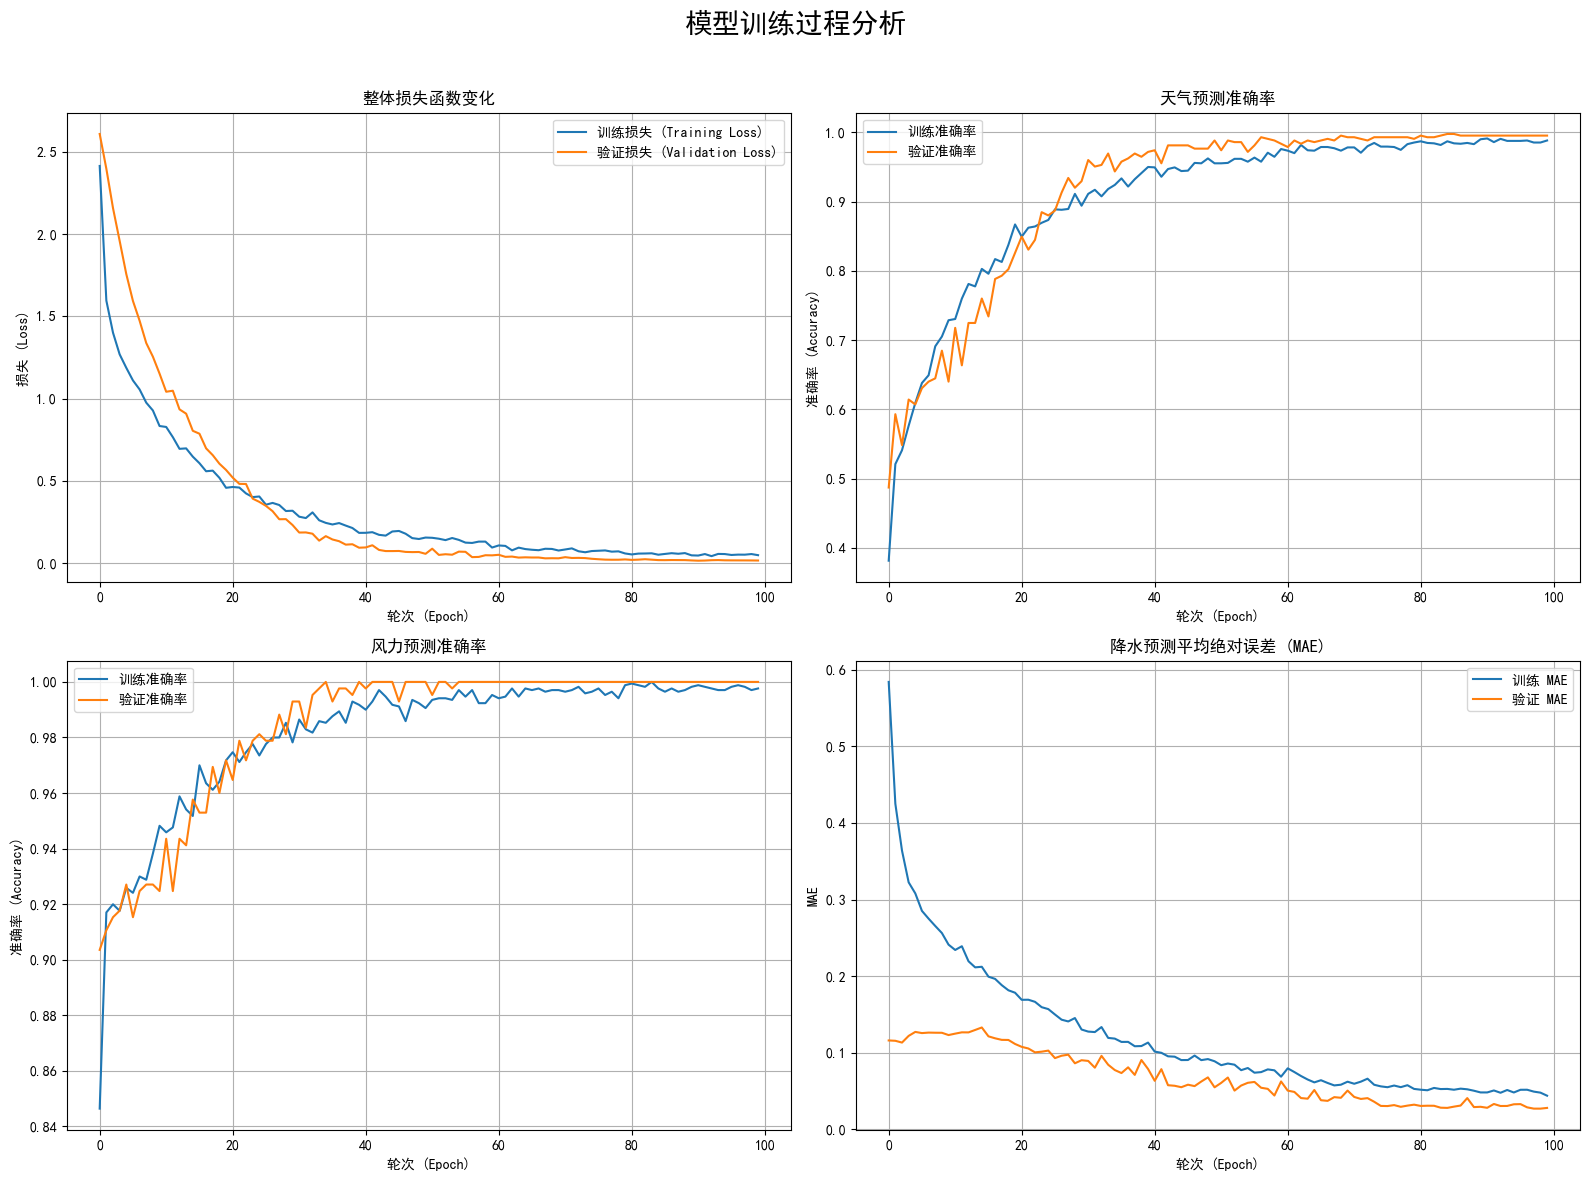


--- 2. 天气 预测性能分析 ---


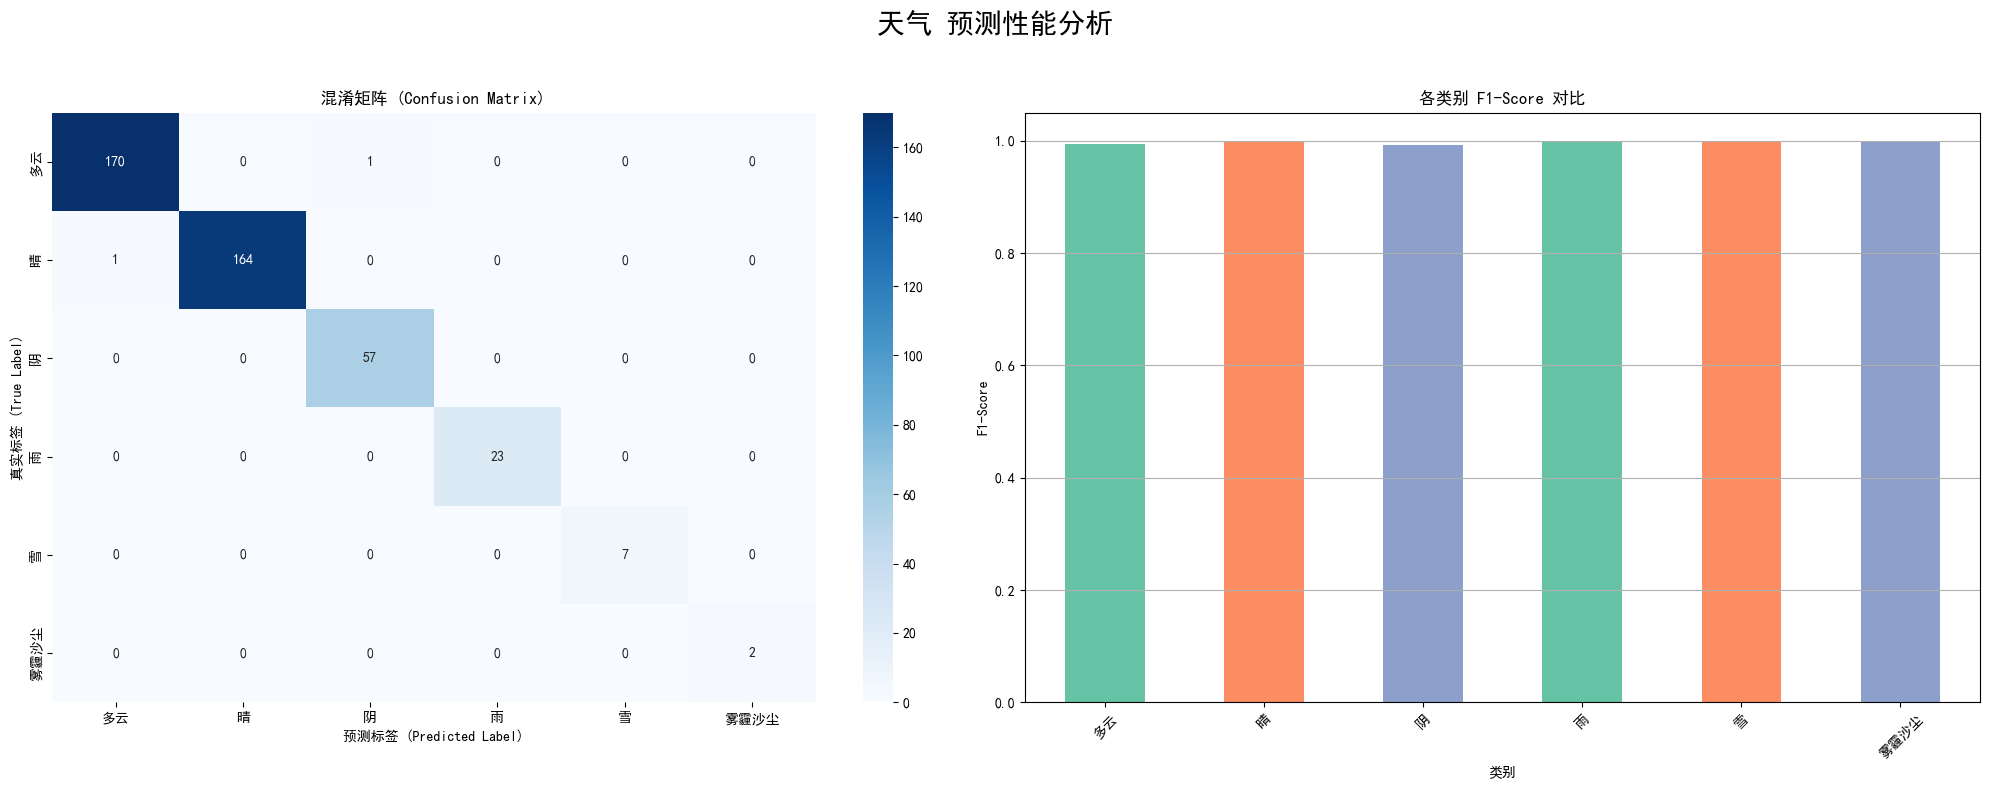


天气 分类报告详情:
              precision    recall  f1-score   support

          多云       0.99      0.99      0.99       171
           晴       1.00      0.99      1.00       165
           阴       0.98      1.00      0.99        57
           雨       1.00      1.00      1.00        23
           雪       1.00      1.00      1.00         7
        雾霾沙尘       1.00      1.00      1.00         2

    accuracy                           1.00       425
   macro avg       1.00      1.00      1.00       425
weighted avg       1.00      1.00      1.00       425


--- 2. 风力等级 预测性能分析 ---


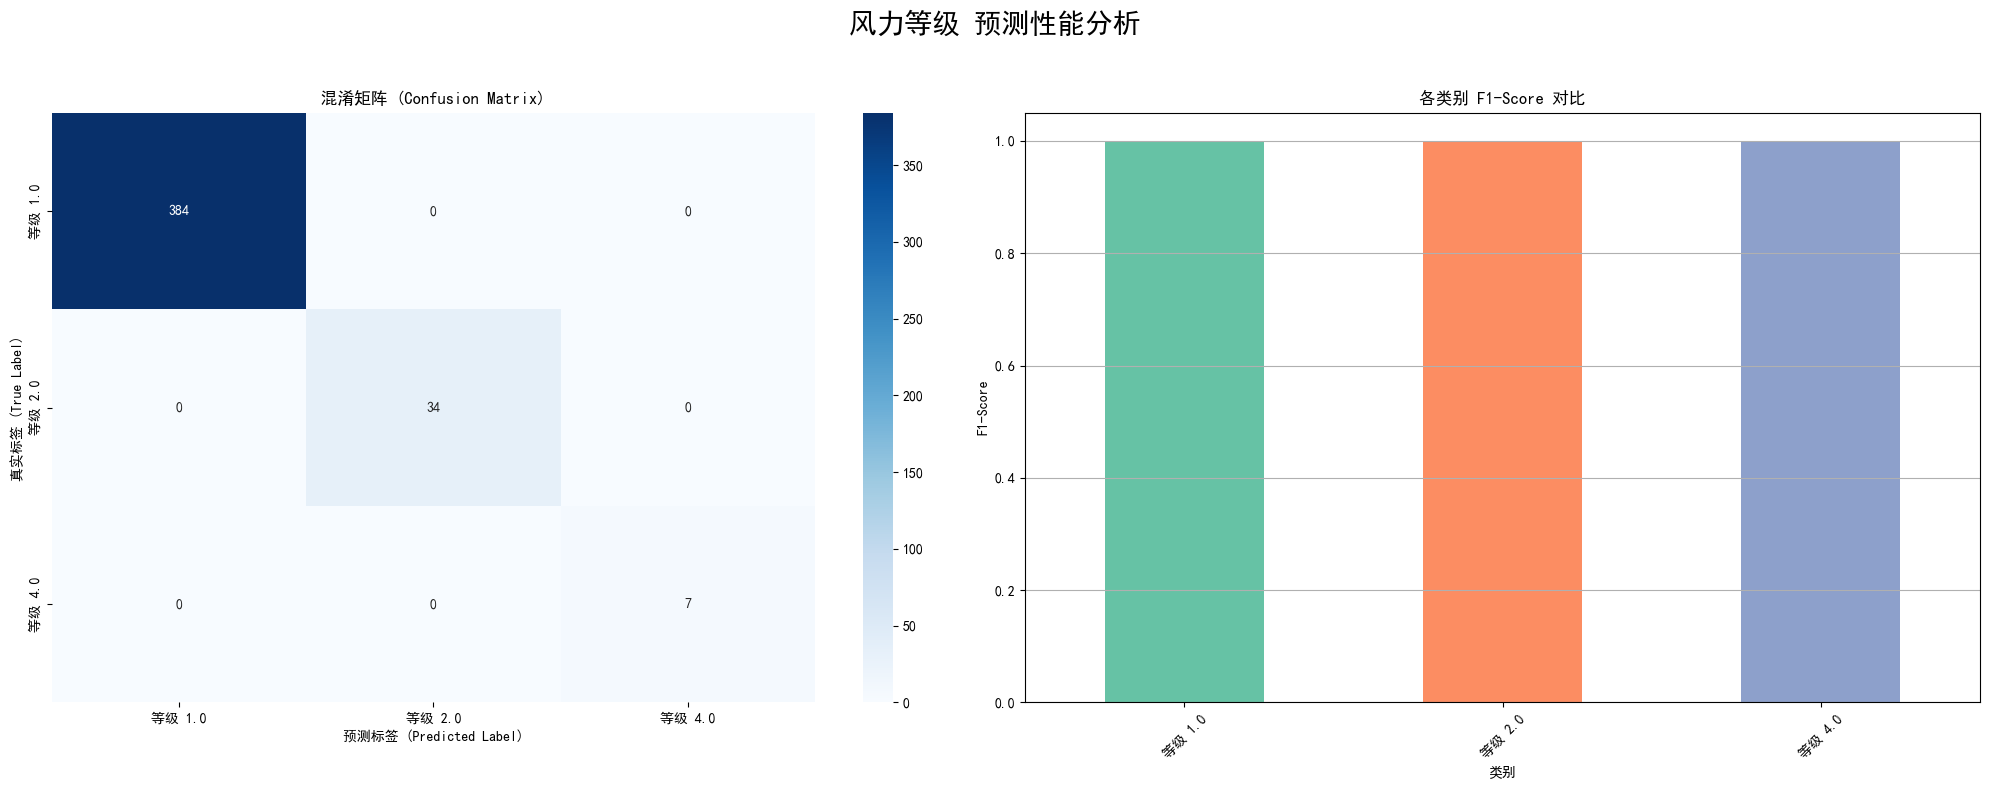


风力等级 分类报告详情:
              precision    recall  f1-score   support

      等级 1.0       1.00      1.00      1.00       384
      等级 2.0       1.00      1.00      1.00        34
      等级 4.0       1.00      1.00      1.00         7

    accuracy                           1.00       425
   macro avg       1.00      1.00      1.00       425
weighted avg       1.00      1.00      1.00       425


--- 3. 降水强度预测性能分析 ---


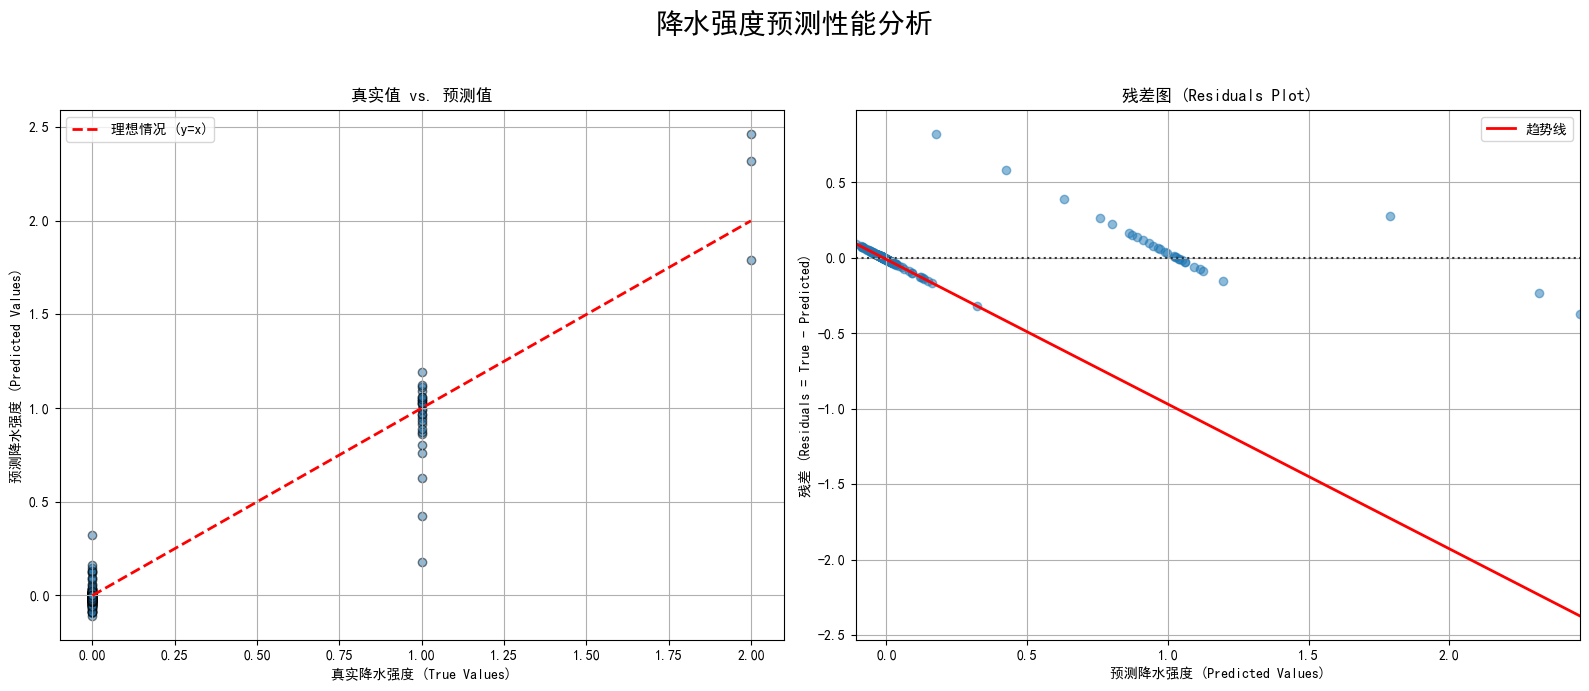


--- 4. 特征重要性分析 (Permutation Importance) ---
正在计算置换重要性，这可能需要一些时间...


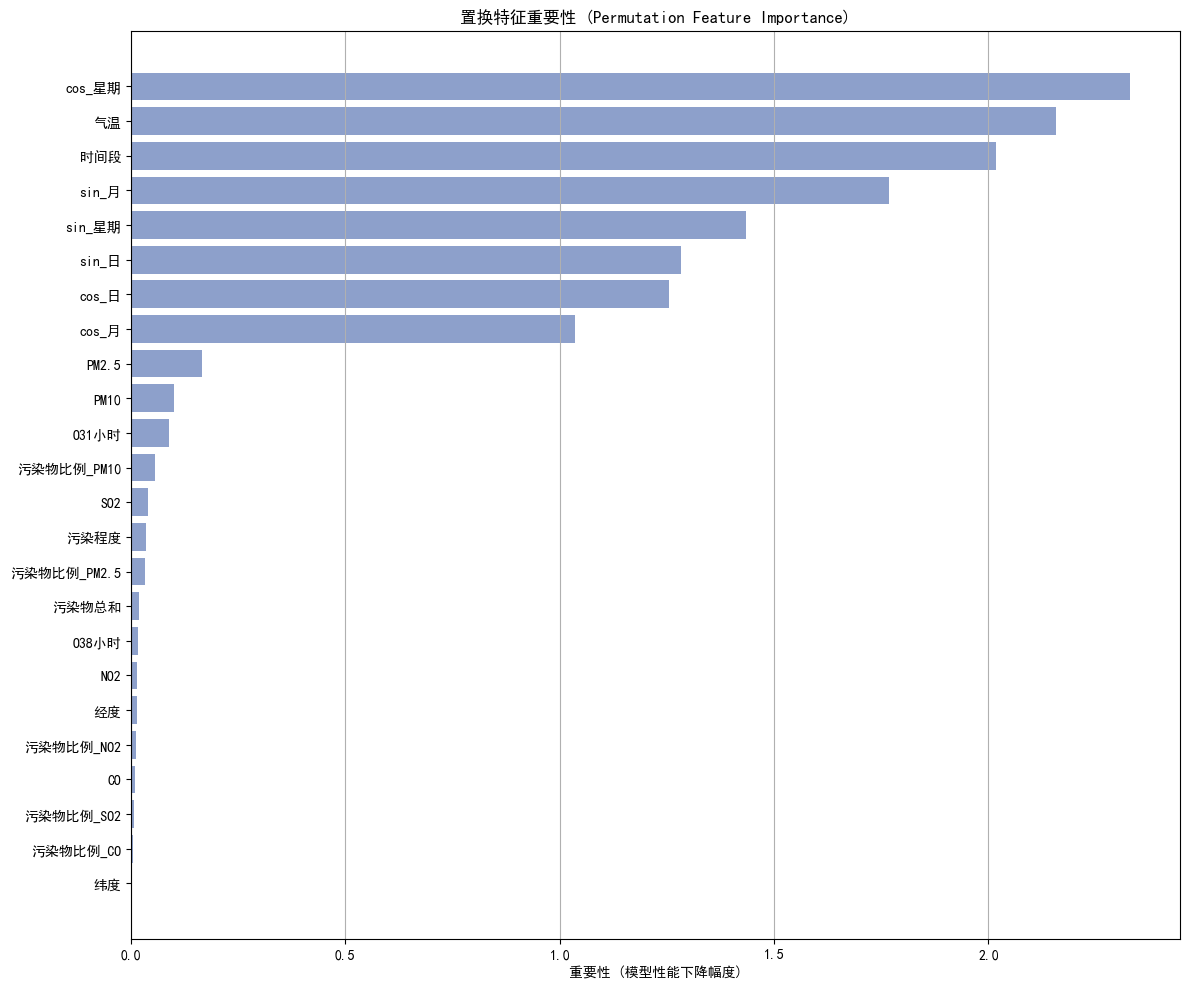



========================= 示例预测 =========================


ValueError: 此方法仅适用于序列模型

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Input, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

class ModelVisualizer:
    def __init__(self, predictor, test_data, feature_names):
        """
        初始化可视化分析器。
        
        参数:
            predictor (EnvironmentalPredictor): 训练好的 EnvironmentalPredictor 实例。
            test_data (tuple): 包含 (X_test, y_test_dict) 的元组。
            feature_names (list): 特征名称列表。
        """
        if not predictor.is_fitted:
            raise ValueError("传入的 predictor 必须是已经训练好的模型。")
            
        self.predictor = predictor
        self.model = predictor.model
        self.X_test, self.y_test = test_data
        self.feature_names = feature_names
        self.use_sequences = predictor.use_sequences
        
        # 获取预测结果
        print("正在生成用于可视化的预测结果...")
        self.predictions = self.model.predict(self.X_test)
        
        # 解码预测和真实标签
        self.weather_pred_labels = np.argmax(self.predictions[0], axis=1)
        self.weather_true_labels = self.y_test['weather_output']
        self.weather_class_names = self.predictor.weather_encoder.classes_
        
        self.wind_pred_labels = np.argmax(self.predictions[1], axis=1)
        self.wind_true_labels = self.y_test['wind_output']
        
        self.rain_pred = self.predictions[2].flatten()
        self.rain_true = self.y_test['rain_output']
        print("初始化完成，可以开始绘图。")

    def plot_training_history(self, history):
        """绘制训练历史曲线"""
        print("\n--- 1. 绘制训练过程历史 ---")
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('模型训练过程分析', fontsize=20)
        
        # 总损失
        axes[0, 0].plot(history.history['loss'], label='训练损失 (Training Loss)')
        axes[0, 0].plot(history.history['val_loss'], label='验证损失 (Validation Loss)')
        axes[0, 0].set_title('整体损失函数变化')
        axes[0, 0].set_xlabel('轮次 (Epoch)')
        axes[0, 0].set_ylabel('损失 (Loss)')
        axes[0, 0].legend()
        axes[0, 0].grid(True)
        
        # 天气预测准确率
        axes[0, 1].plot(history.history['weather_output_accuracy'], label='训练准确率')
        axes[0, 1].plot(history.history['val_weather_output_accuracy'], label='验证准确率')
        axes[0, 1].set_title('天气预测准确率')
        axes[0, 1].set_xlabel('轮次 (Epoch)')
        axes[0, 1].set_ylabel('准确率 (Accuracy)')
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # 风力预测准确率
        axes[1, 0].plot(history.history['wind_output_accuracy'], label='训练准确率')
        axes[1, 0].plot(history.history['val_wind_output_accuracy'], label='验证准确率')
        axes[1, 0].set_title('风力预测准确率')
        axes[1, 0].set_xlabel('轮次 (Epoch)')
        axes[1, 0].set_ylabel('准确率 (Accuracy)')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
        
        # 降水预测MAE
        axes[1, 1].plot(history.history['rain_output_mae'], label='训练 MAE')
        axes[1, 1].plot(history.history['val_rain_output_mae'], label='验证 MAE')
        axes[1, 1].set_title('降水预测平均绝对误差 (MAE)')
        axes[1, 1].set_xlabel('轮次 (Epoch)')
        axes[1, 1].set_ylabel('MAE')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def plot_classification_analysis(self, task_name, true_labels, pred_labels, class_names):
        """
        为分类任务（天气/风力）绘制混淆矩阵和分类报告图。
        """
        print(f"\n--- 2. {task_name} 预测性能分析 ---")
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        fig.suptitle(f'{task_name} 预测性能分析', fontsize=20)

        # 2a. 混淆矩阵
        cm = confusion_matrix(true_labels, pred_labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names, ax=axes[0])
        axes[0].set_title('混淆矩阵 (Confusion Matrix)')
        axes[0].set_xlabel('预测标签 (Predicted Label)')
        axes[0].set_ylabel('真实标签 (True Label)')

        # 2b. 分类报告可视化
        report = classification_report(true_labels, pred_labels, 
                                       target_names=class_names, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        report_df.drop(['accuracy', 'macro avg', 'weighted avg'], inplace=True)
        report_df['f1-score'].plot(kind='bar', ax=axes[1], color=['#66c2a5', '#fc8d62', '#8da0cb'])
        axes[1].set_title('各类别 F1-Score 对比')
        axes[1].set_xlabel('类别')
        axes[1].set_ylabel('F1-Score')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        
        # 打印详细报告以供参考
        print(f"\n{task_name} 分类报告详情:")
        print(classification_report(true_labels, pred_labels, target_names=class_names))

    def plot_regression_analysis(self):
        """为回归任务（降水）绘制分析图。"""
        print("\n--- 3. 降水强度预测性能分析 ---")
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle('降水强度预测性能分析', fontsize=20)

        # 3a. 真实值 vs 预测值
        axes[0].scatter(self.rain_true, self.rain_pred, alpha=0.5, edgecolors='k')
        axes[0].plot([self.rain_true.min(), self.rain_true.max()], 
                     [self.rain_true.min(), self.rain_true.max()], 
                     'r--', lw=2, label='理想情况 (y=x)')
        axes[0].set_title('真实值 vs. 预测值')
        axes[0].set_xlabel('真实降水强度 (True Values)')
        axes[0].set_ylabel('预测降水强度 (Predicted Values)')
        axes[0].legend()
        axes[0].grid(True)

        # 3b. 残差图
        residuals = self.rain_true - self.rain_pred
        sns.residplot(x=self.rain_pred, y=residuals, lowess=True, 
                      ax=axes[1], scatter_kws={'alpha': 0.5},
                      line_kws={'color': 'red', 'lw': 2, 'label': '趋势线'})
        axes[1].set_title('残差图 (Residuals Plot)')
        axes[1].set_xlabel('预测降水强度 (Predicted Values)')
        axes[1].set_ylabel('残差 (Residuals = True - Predicted)')
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    def plot_permutation_feature_importance(self):
        """
        计算并绘制置换特征重要性。
        - 对于非时序数据(2D)，使用 sklearn 的 permutation_importance。
        - 对于时序数据(3D)，手动实现置换重要性计算。
        """
        print("\n--- 4. 特征重要性分析 (Permutation Importance) ---")

        # 检查是否为时序数据
        if self.use_sequences:
            print("检测到序列模型(3D数据)，将使用手动实现的置换重要性分析。")
            print("注意: 此过程可能会非常耗时。")
            
            # 1. 手动为3D数据实现置换重要性
            print("正在计算基准性能...")
            baseline_loss = self.model.evaluate(self.X_test, self.y_test, verbose=0)
            baseline_score = -baseline_loss[0]
            print(f"基准得分 (负总损失): {baseline_score:.4f}")

            importances = []
            n_features = self.X_test.shape[2]

            for i in range(n_features):
                feature_name = self.feature_names[i]
                print(f"正在置换特征 {i+1}/{n_features}: {feature_name}...")
                X_test_permuted = self.X_test.copy()
                original_feature_slice = X_test_permuted[:, :, i]
                permuted_slice = np.random.permutation(original_feature_slice.flatten()).reshape(original_feature_slice.shape)
                X_test_permuted[:, :, i] = permuted_slice
                permuted_loss = self.model.evaluate(X_test_permuted, self.y_test, verbose=0)
                permuted_score = -permuted_loss[0]
                importance = baseline_score - permuted_score
                importances.append(importance)
            importances_mean = np.array(importances)
            perm_sorted_idx = importances_mean.argsort()
        else:
            # 修复：Keras模型不能直接用于多进程并行，需强制 n_jobs=1
            class KerasSklearnWrapper:
                def __init__(self, model): self.model = model
                def fit(self, X, y): pass
                def predict(self, X): return self.model.predict(X)

            def custom_scorer(estimator, X, y):
                loss = estimator.model.evaluate(X, y, verbose=0)
                return -loss[0]

            sklearn_compatible_estimator = KerasSklearnWrapper(self.model)
            print("正在计算置换重要性，这可能需要一些时间...")
            result = permutation_importance(
                estimator=sklearn_compatible_estimator,
                X=self.X_test, 
                y=self.y_test,
                scoring=custom_scorer,
                n_repeats=10,
                random_state=42,
                n_jobs=1  # 关键修复：避免多进程导致 Keras 不能序列化
            )
            importances_mean = result.importances_mean
            perm_sorted_idx = importances_mean.argsort()

        # 展示结果
        importance_df = pd.DataFrame(
            data={'feature': np.array(self.feature_names)[perm_sorted_idx],
                  'importance': importances_mean[perm_sorted_idx]}
        )
        
        plt.figure(figsize=(12, 10))
        plt.barh(importance_df['feature'], importance_df['importance'], color='#8da0cb')
        plt.title('置换特征重要性 (Permutation Feature Importance)')
        plt.xlabel('重要性 (模型性能下降幅度)')
        plt.grid(axis='x')
        plt.tight_layout()
        plt.show()

class EnvironmentalPredictor:
    def __init__(self):
        self.scaler_features = StandardScaler()
        self.scaler_continuous_targets = StandardScaler()
        self.weather_encoder = None
        self.is_fitted = False
        self.use_sequences = False
        self.sequence_length = None
        self.feature_names = None
        
    def save_model(self, model_path='saved_model'):
        """保存模型及预处理器"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，无法保存。")

        os.makedirs(model_path, exist_ok=True)
        
        # 保存 Keras 模型
        self.model.save(os.path.join(model_path, 'model.h5'))

        # 保存缩放器和编码器
        joblib.dump(self.scaler_features, os.path.join(model_path, 'scaler_features.pkl'))
        joblib.dump(self.weather_encoder, os.path.join(model_path, 'weather_encoder.pkl'))

        # 保存元信息
        with open(os.path.join(model_path, 'meta_info.txt'), 'w') as f:
            f.write(f"use_sequences={self.use_sequences}\n")
            if self.use_sequences:
                f.write(f"sequence_length={self.sequence_length}\n")
            f.write(f"feature_names={','.join(self.feature_names)}\n")
        
        print(f"模型和预处理器已保存至：{model_path}")
        
    def load_model(self, model_path='saved_model'):
        """加载模型及预处理器"""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"模型路径不存在: {model_path}")

        # 加载 Keras 模型
        self.model = tf.keras.models.load_model(os.path.join(model_path, 'model.h5'))

        # 加载缩放器和编码器
        self.scaler_features = joblib.load(os.path.join(model_path, 'scaler_features.pkl'))
        self.weather_encoder = joblib.load(os.path.join(model_path, 'weather_encoder.pkl'))

        # 读取元信息
        meta_info_path = os.path.join(model_path, 'meta_info.txt')
        if os.path.exists(meta_info_path):
            with open(meta_info_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if line.startswith("use_sequences="):
                        self.use_sequences = line.strip().split('=')[1].lower() == 'true'
                    elif line.startswith("sequence_length="):
                        self.sequence_length = int(line.strip().split('=')[1])
                    elif line.startswith("feature_names="):
                        self.feature_names = line.strip().split('=')[1].split(',')
        
        self.is_fitted = True
        print(f"模型和预处理器已从 {model_path} 成功加载。")

    def load_and_preprocess_data(self, file_path):
        """加载和预处理数据"""
        # 读取数据
        columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', 
                  '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                  '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        data = pd.read_csv(file_path, usecols=columns)
        
        # 处理日期
        data['日期'] = pd.to_datetime(data['日期'])
        data['年'] = data['日期'].dt.year
        data['月'] = data['日期'].dt.month
        data['日'] = data['日期'].dt.day
        data['星期'] = data['日期'].dt.dayofweek
        
        # 创建天气标签（从one-hot转换）
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        data['天气类别'] = data[weather_cols].idxmax(axis=1).str.replace('天气_', '')
        
        # 特征工程：添加时间特征
        data['sin_月'] = np.sin(2 * np.pi * data['月'] / 12)
        data['cos_月'] = np.cos(2 * np.pi * data['月'] / 12)
        data['sin_日'] = np.sin(2 * np.pi * data['日'] / 31)
        data['cos_日'] = np.cos(2 * np.pi * data['日'] / 31)
        data['sin_星期'] = np.sin(2 * np.pi * data['星期'] / 7)
        data['cos_星期'] = np.cos(2 * np.pi * data['星期'] / 7)
        
        # 添加空间特征
        data['位置hash'] = data['纬度'].astype(str) + '_' + data['经度'].astype(str)
        
        # 添加污染物综合指标
        data['污染物总和'] = data['SO2'] + data['NO2'] + data['PM10'] + data['CO'] + data['PM2.5']
        data['污染物比例_SO2'] = data['SO2'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_NO2'] = data['NO2'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_PM10'] = data['PM10'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_CO'] = data['CO'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_PM2.5'] = data['PM2.5'] / (data['污染物总和'] + 1e-8)
        
        return data
    
    def create_sequences(self, data, sequence_length=24, forecast_steps=10):
        """创建时序序列数据"""
        # 按位置分组
        grouped = data.groupby('位置hash')
        
        sequences_X = []
        sequences_y_weather = []
        sequences_y_wind = []
        sequences_y_rain = []
        sequences_y_all = []  # 用于预测所有特征的序列
        
        for location, group in grouped:
            if len(group) < sequence_length + forecast_steps:
                continue
                
            group_sorted = group.sort_values(['日期', '时间段'])
            
            for i in range(len(group_sorted) - sequence_length - forecast_steps + 1):
                # 输入特征序列
                seq_features = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5',
                              '污染程度', '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                              'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                              '污染物比例_NO2', '污染物比例_PM10', '污染物比例_CO', '污染物比例_PM2.5']
                
                seq_X = group_sorted[seq_features].iloc[i:i+sequence_length].values
                
                # 目标变量（预测未来forecast_steps个时间点）
                target_start = i + sequence_length
                target_end = target_start + forecast_steps
                
                # 天气、风力、降水目标
                target_row = group_sorted.iloc[target_start:target_end]
                
                sequences_X.append(seq_X)
                sequences_y_weather.append(target_row['天气类别'].values[-1])  # 只预测最后一个时间点
                sequences_y_wind.append(target_row['风力编码'].values[-1])
                sequences_y_rain.append(target_row['降水强度'].values[-1])
                
                # 所有特征的目标 (用于多特征预测)
                all_features_target = group_sorted[seq_features].iloc[target_start:target_end].values
                sequences_y_all.append(all_features_target)
        
        return (np.array(sequences_X), 
                np.array(sequences_y_weather), 
                np.array(sequences_y_wind), 
                np.array(sequences_y_rain),
                np.array(sequences_y_all))
    
    def prepare_non_sequential_data(self, data):
        """准备非时序数据"""
        # 输入特征
        feature_cols = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5',
                       '污染程度', '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                       'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                       '污染物比例_NO2', '污染物比例_PM10', '污染物比例_CO', '污染物比例_PM2.5']
        
        X = data[feature_cols].values
        y_weather = data['天气类别'].values
        y_wind = data['风力编码'].values
        y_rain = data['降水强度'].values
        
        return X, y_weather, y_wind, y_rain
    
    def build_lstm_model(self, input_shape, n_weather_classes, max_wind, max_rain, forecast_steps=10):
        """构建LSTM多输出模型"""
        # 输入层
        input_layer = Input(shape=input_shape)
        
        # LSTM层
        lstm1 = LSTM(256, return_sequences=True, dropout=0.2)(input_layer)
        lstm2 = LSTM(128, return_sequences=True, dropout=0.2)(lstm1)
        lstm3 = LSTM(64, dropout=0.2)(lstm2)
        
        # 批归一化
        bn = BatchNormalization()(lstm3)
        
        # 共享的全连接层
        shared_dense = Dense(128, activation='relu')(bn)
        shared_dense = Dropout(0.3)(shared_dense)
        
        # 天气预测分支
        weather_branch = Dense(64, activation='relu', name='weather_dense')(shared_dense)
        weather_output = Dense(n_weather_classes, activation='softmax', name='weather_output')(weather_branch)
        
        # 风力预测分支
        wind_branch = Dense(64, activation='relu', name='wind_dense')(shared_dense)
        wind_output = Dense(max_wind + 1, activation='softmax', name='wind_output')(wind_branch)
        
        # 降水预测分支
        rain_branch = Dense(64, activation='relu', name='rain_dense')(shared_dense)
        rain_output = Dense(1, activation='linear', name='rain_output')(rain_branch)
        
        # 所有特征预测分支 (新增)
        all_features_branch = Dense(128, activation='relu')(shared_dense)
        all_features_branch = Dropout(0.3)(all_features_branch)
        all_features_output = Dense(input_shape[-1] * forecast_steps, activation='linear', 
                                  name='all_features_output')(all_features_branch)
        all_features_output = tf.keras.layers.Reshape((forecast_steps, input_shape[-1]))(all_features_output)
        
        # 构建模型
        model = Model(inputs=input_layer, 
                     outputs=[weather_output, wind_output, rain_output, all_features_output])
        
        return model
    
    def build_dense_model(self, input_shape, n_weather_classes, max_wind, max_rain):
        """构建全连接多输出模型"""
        # 输入层
        input_layer = Input(shape=(input_shape,))
        
        # 隐藏层
        dense1 = Dense(512, activation='relu')(input_layer)
        dense1 = BatchNormalization()(dense1)
        dense1 = Dropout(0.4)(dense1)
        
        dense2 = Dense(256, activation='relu')(dense1)
        dense2 = BatchNormalization()(dense2)
        dense2 = Dropout(0.3)(dense2)
        
        dense3 = Dense(128, activation='relu')(dense2)
        dense3 = Dropout(0.2)(dense3)
        
        # 天气预测分支
        weather_branch = Dense(64, activation='relu')(dense3)
        weather_output = Dense(n_weather_classes, activation='softmax', name='weather_output')(weather_branch)
        
        # 风力预测分支
        wind_branch = Dense(64, activation='relu')(dense3)
        wind_output = Dense(max_wind + 1, activation='softmax', name='wind_output')(wind_branch)
        
        # 降水预测分支
        rain_branch = Dense(64, activation='relu')(dense3)
        rain_output = Dense(1, activation='linear', name='rain_output')(rain_branch)
        
        # 构建模型
        model = Model(inputs=input_layer, 
                     outputs=[weather_output, wind_output, rain_output])
        
        return model
    
    def train_models(self, data, use_sequences=True, sequence_length=12, forecast_steps=10):
        """训练模型"""
        print("开始数据预处理...")
        
        # 编码器准备
        self.weather_encoder = LabelEncoder()
        weather_encoded = self.weather_encoder.fit_transform(data['天气类别'])
        
        if use_sequences:
            print("创建时序序列...")
            X, y_weather, y_wind, y_rain, y_all = self.create_sequences(
                data, sequence_length, forecast_steps)
            if len(X) == 0:
                print("序列数据不足，切换到非时序模式...")
                use_sequences = False
        
        if not use_sequences:
            print("使用非时序数据...")
            X, y_weather, y_wind, y_rain = self.prepare_non_sequential_data(data)
            y_all = None
            
        # 编码目标变量
        y_weather_encoded = self.weather_encoder.transform(y_weather)
        
        # 标准化特征
        if use_sequences:
            # 对于序列数据，需要重塑后标准化
            X_reshaped = X.reshape(-1, X.shape[-1])
            X_scaled_reshaped = self.scaler_features.fit_transform(X_reshaped)
            X_scaled = X_scaled_reshaped.reshape(X.shape)
        else:
            X_scaled = self.scaler_features.fit_transform(X)
        
        # 划分训练测试集
        if use_sequences:
            X_train, X_test, y_weather_train, y_weather_test, y_wind_train, y_wind_test, y_rain_train, y_rain_test, y_all_train, y_all_test = \
                train_test_split(X_scaled, y_weather_encoded, y_wind, y_rain, y_all, test_size=0.2, random_state=42)
        else:
            X_train, X_test, y_weather_train, y_weather_test, y_wind_train, y_wind_test, y_rain_train, y_rain_test = \
                train_test_split(X_scaled, y_weather_encoded, y_wind, y_rain, test_size=0.2, random_state=42)
            y_all_train, y_all_test = None, None
        
        # 获取类别数量
        n_weather_classes = len(self.weather_encoder.classes_)
        # 确保风力和降水为整数类型
        y_wind = y_wind.astype(int)
        y_rain = y_rain.astype(int)
        max_wind = int(np.max(y_wind).item())
        max_rain = int(np.max(y_rain).item())
        
        print(f"天气类别数: {n_weather_classes}")
        print(f"最大风力: {max_wind}")
        print(f"最大降水强度: {max_rain}")
        
        # 构建模型
        if use_sequences:
            print("构建LSTM模型...")
            model = self.build_lstm_model(X_train.shape[1:], n_weather_classes, max_wind, max_rain, forecast_steps)
        else:
            print("构建全连接模型...")
            model = self.build_dense_model(X_train.shape[1], n_weather_classes, max_wind, max_rain)
        
        # 编译模型
        if use_sequences:
            model.compile(
                optimizer=Adam(learning_rate=0.001),
                loss={
                    'weather_output': 'sparse_categorical_crossentropy',
                    'wind_output': 'sparse_categorical_crossentropy',
                    'rain_output': 'mse',
                    'all_features_output': 'mse'
                },
                loss_weights={
                    'weather_output': 1.0,
                    'wind_output': 1.0,
                    'rain_output': 0.5,
                    'all_features_output': 0.3
                },
                metrics={
                    'weather_output': 'accuracy',
                    'wind_output': 'accuracy',
                    'rain_output': 'mae',
                    'all_features_output': 'mae'
                }
            )
        else:
            model.compile(
                optimizer=Adam(learning_rate=0.001),
                loss={
                    'weather_output': 'sparse_categorical_crossentropy',
                    'wind_output': 'sparse_categorical_crossentropy',
                    'rain_output': 'mse'
                },
                loss_weights={
                    'weather_output': 1.0,
                    'wind_output': 1.0,
                    'rain_output': 0.5
                },
                metrics={
                    'weather_output': 'accuracy',
                    'wind_output': 'accuracy',
                    'rain_output': 'mae'
                }
            )
        
        print("模型结构:")
        model.summary()
        
        # 回调函数
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        ]
        
        # 训练模型
        print("开始训练...")
        if use_sequences:
            history = model.fit(
                X_train,
                {
                    'weather_output': y_weather_train,
                    'wind_output': y_wind_train,
                    'rain_output': y_rain_train,
                    'all_features_output': y_all_train
                },
                validation_data=(
                    X_test,
                    {
                        'weather_output': y_weather_test,
                        'wind_output': y_wind_test,
                        'rain_output': y_rain_test,
                        'all_features_output': y_all_test
                    }
                ),
                epochs=150,
                batch_size=64,
                callbacks=callbacks,
                verbose=1
            )
        else:
            history = model.fit(
                X_train,
                {
                    'weather_output': y_weather_train,
                    'wind_output': y_wind_train,
                    'rain_output': y_rain_train
                },
                validation_data=(
                    X_test,
                    {
                        'weather_output': y_weather_test,
                        'wind_output': y_wind_test,
                        'rain_output': y_rain_test
                    }
                ),
                epochs=100,
                batch_size=128,
                callbacks=callbacks,
                verbose=1
            )
        
        # 评估模型
        print("\n模型评估:")
        predictions = model.predict(X_test)
        
        # 天气预测评估
        weather_pred = np.argmax(predictions[0], axis=1)
        weather_acc = accuracy_score(y_weather_test, weather_pred)
        print(f"天气预测准确率: {weather_acc:.4f}")
        
        # 风力预测评估
        wind_pred = np.argmax(predictions[1], axis=1)
        wind_acc = accuracy_score(y_wind_test, wind_pred)
        print(f"风力预测准确率: {wind_acc:.4f}")
        
        # 降水预测评估
        rain_pred = predictions[2].flatten()
        rain_mse = mean_squared_error(y_rain_test, rain_pred)
        rain_mae = mean_absolute_error(y_rain_test, rain_pred)
        print(f"降水预测 MSE: {rain_mse:.4f}")
        print(f"降水预测 MAE: {rain_mae:.4f}")
        
        # 所有特征预测评估 (仅时序模型)
        if use_sequences:
            all_features_pred = predictions[3]
            all_features_mse = mean_squared_error(y_all_test.reshape(-1), all_features_pred.reshape(-1))
            all_features_mae = mean_absolute_error(y_all_test.reshape(-1), all_features_pred.reshape(-1))
            print(f"所有特征预测 MSE: {all_features_mse:.4f}")
            print(f"所有特征预测 MAE: {all_features_mae:.4f}")
        
        # 详细分类报告
        print("\n天气预测详细报告:")
        print(classification_report(y_weather_test, weather_pred, 
                                  target_names=self.weather_encoder.classes_))
        
        self.model = model
        self.is_fitted = True
        self.use_sequences = use_sequences
        self.sequence_length = sequence_length if use_sequences else None
        self.feature_names = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5',
                             '污染程度', '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                             'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                             '污染物比例_NO2', '污染物比例_PM10', '污染物比例_CO', '污染物比例_PM2.5']
        
        y_test_dict = {
            'weather_output': y_weather_test,
            'wind_output': y_wind_test,
            'rain_output': y_rain_test
        }
        
        if use_sequences:
            y_test_dict['all_features_output'] = y_all_test
        
        return history, (X_test, y_test_dict), self.feature_names
    
    def predict_future(self, input_data, steps=10):
        """
        预测未来多个时间步
        参数:
            input_data: 最后n个时间步的数据 (shape: [sequence_length, n_features])
            steps: 要预测的未来时间步数
        返回:
            预测结果字典，包含未来steps个时间步的所有特征预测
        """
        if not self.is_fitted:
            raise ValueError("模型尚未训练，请先调用train_models方法")
        if not self.use_sequences:
            raise ValueError("此方法仅适用于序列模型")
        
        # 标准化输入数据
        input_reshaped = input_data.reshape(-1, input_data.shape[-1])
        input_scaled_reshaped = self.scaler_features.transform(input_reshaped)
        input_scaled = input_scaled_reshaped.reshape(1, input_data.shape[0], input_data.shape[1])
        
        # 预测
        predictions = self.model.predict(input_scaled)
        
        # 获取所有特征预测并反标准化
        all_features_pred = predictions[3][0]  # 取第一个样本的预测
        all_features_pred_reshaped = all_features_pred.reshape(-1, all_features_pred.shape[-1])
        all_features_unscaled = self.scaler_features.inverse_transform(all_features_pred_reshaped)
        all_features_unscaled = all_features_unscaled.reshape(all_features_pred.shape)
        
        # 解码天气预测
        weather_pred = self.weather_encoder.inverse_transform(np.argmax(predictions[0], axis=1))
        wind_pred = np.argmax(predictions[1], axis=1)
        rain_pred = predictions[2].flatten()
        
        return {
            'weather': weather_pred[0],
            'wind': wind_pred[0],
            'rain': rain_pred[0],
            'all_features': all_features_unscaled,
            'weather_proba': predictions[0][0],
            'wind_proba': predictions[1][0]
        }
    
    def plot_future_predictions(self, input_data, steps=10):
        """
        可视化未来预测结果
        参数:
            input_data: 最后n个时间步的数据 (shape: [sequence_length, n_features])
            steps: 要预测的未来时间步数
        """
        if not self.is_fitted:
            raise ValueError("模型尚未训练，请先调用train_models方法")
        if not self.use_sequences:
            raise ValueError("此方法仅适用于序列模型")
            
        # 获取预测结果
        predictions = self.predict_future(input_data, steps)
        
        # 准备特征名称
        feature_names = ['SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5',
                       '污染程度', '气温', '降水强度']
        
        # 选择要展示的特征索引
        feature_indices = [2, 3, 4, 5, 6, 7, 8, 9, 11, 15]  # 根据实际特征顺序调整
        
        # 创建子图
        fig, axes = plt.subplots(5, 2, figsize=(18, 20))
        fig.suptitle(f'未来{steps}个时间步的环境特征预测', fontsize=20)
        
        # 绘制每个特征的预测
        for i, (ax, idx) in enumerate(zip(axes.flatten(), feature_indices)):
            feature_name = feature_names[i]
            ax.plot(range(steps), predictions['all_features'][:, idx], 'r-', label='预测值')
            ax.set_title(feature_name)
            ax.set_xlabel('时间步')
            ax.set_ylabel(feature_name)
            ax.grid(True)
            ax.legend()
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # 打印分类预测结果
        print(f"\n未来天气预测: {predictions['weather']}")
        print(f"未来风力预测: 等级 {predictions['wind']}")
        print(f"未来降水强度预测: {predictions['rain']:.2f}")

# 使用示例
def main():
    # 设置中文显示
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 创建预测器实例
    predictor = EnvironmentalPredictor()
    
    # 加载数据
    print("加载数据...")
    data = predictor.load_and_preprocess_data('end_cleaned.csv')
    
    print(f"数据形状: {data.shape}")
    print(f"数据列: {data.columns.tolist()}")
    print(f"天气类别: {data['天气类别'].unique()}")
    print(f"数据日期范围: {data['日期'].min()} 到 {data['日期'].max()}")
    
    # 训练模型
    print("\n训练模型...")
    history, test_data, feature_names = None, None, None
    try:
        history, test_data, feature_names = predictor.train_models(
            data, use_sequences=True, sequence_length=12, forecast_steps=10)
    except Exception as e:
        print(f"时序模型训练失败: {e}")
        print("切换到非时序模型...")
        history, test_data, feature_names = predictor.train_models(
            data, use_sequences=False)
    
    # 保存模型
    predictor.save_model('my_environment_model2')
    
    # 可视化分析
    if history and test_data:
        print("\n\n" + "="*25 + " 模型可视化分析 " + "="*25)
        visualizer = ModelVisualizer(predictor, test_data, feature_names)
        
        visualizer.plot_training_history(history)
        
        # 分析天气预测
        visualizer.plot_classification_analysis(
            task_name="天气",
            true_labels=visualizer.weather_true_labels,
            pred_labels=visualizer.weather_pred_labels,
            class_names=visualizer.weather_class_names
        )
        
        # 分析风力预测
        # 修复：风力类别数和 class_names 不一致导致 classification_report 报错
        wind_labels = np.unique(visualizer.wind_true_labels)
        wind_class_names = [f"等级 {i}" for i in wind_labels]
        visualizer.plot_classification_analysis(
            task_name="风力等级",
            true_labels=visualizer.wind_true_labels,
            pred_labels=visualizer.wind_pred_labels,
            class_names=wind_class_names
        )
        # 分析降水预测
        visualizer.plot_regression_analysis()
        
        # 分析特征重要性
        visualizer.plot_permutation_feature_importance()
    

if __name__ == "__main__":
    main()

加载预训练模型...
模型信息: 使用序列=False, 序列长度=12
特征数量: 24

准备输入数据...
数据加载成功，共12行数据
数据日期范围: 2013-04-26 00:00:00 到 2013-04-26 00:00:00
输入数据形状: (1, 24)

进行预测...
1/1 [==============================] - 0s 82ms/step

预测结果：
未来天气: 晴
天气预测置信度: 1.000
未来风力: 等级 1
风力预测置信度: 1.000
未来降水强度: -0.01

生成可视化图表...


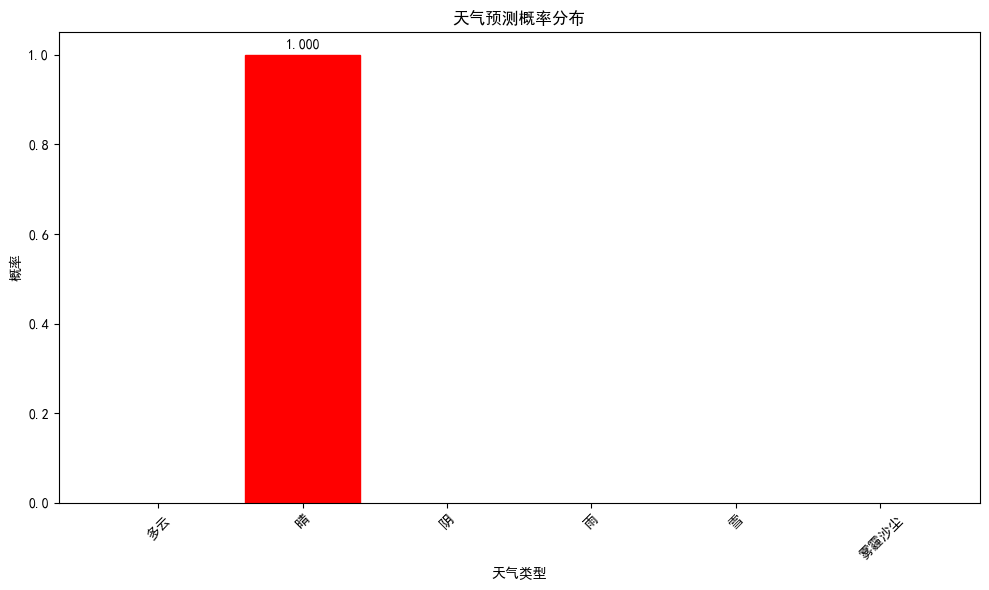

该模型不支持所有特征预测，无法绘制污染物图表


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import matplotlib.pyplot as plt
import os

plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False

class EnvironmentPredictor:
    def __init__(self, model_dir='saved_model'):
        """加载预训练模型和预处理工具"""
        # 加载模型
        self.model = load_model(os.path.join(model_dir, 'model.h5'))
        
        # 加载预处理工具
        self.scaler = joblib.load(os.path.join(model_dir, 'scaler_features.pkl'))
        self.weather_encoder = joblib.load(os.path.join(model_dir, 'weather_encoder.pkl'))
        
        # 加载元信息
        self.use_sequences = True
        self.sequence_length = 12  # 默认值，会从文件中读取
        
        meta_file = os.path.join(model_dir, 'meta_info.txt')
        if os.path.exists(meta_file):
            with open(meta_file, 'r') as f:
                for line in f:
                    if line.startswith('feature_names='):
                        self.feature_names = line.strip().split('=')[1].split(',')
                    elif line.startswith('sequence_length='):
                        self.sequence_length = int(line.strip().split('=')[1])
                    elif line.startswith('use_sequences='):
                        self.use_sequences = line.strip().split('=')[1].lower() == 'true'
        
        print(f"模型信息: 使用序列={self.use_sequences}, 序列长度={self.sequence_length}")
        print(f"特征数量: {len(self.feature_names)}")

    def prepare_input(self, raw_data):
        """
        准备输入数据
        参数:
            raw_data: 原始DataFrame，需包含模型训练时的所有特征列
        返回:
            标准化后的输入数据
        """
        if self.use_sequences:
            # 确保有足够的数据
            if len(raw_data) < self.sequence_length:
                raise ValueError(f"数据长度不足，需要至少{self.sequence_length}个时间步，但只有{len(raw_data)}个")
            
            # 取最后N个时间步
            input_data = raw_data[self.feature_names].iloc[-self.sequence_length:].values
            
            # 标准化
            input_reshaped = input_data.reshape(-1, len(self.feature_names))
            input_scaled = self.scaler.transform(input_reshaped)
            return input_scaled.reshape(1, self.sequence_length, -1)  # 添加batch维度
        else:
            # 非序列模式，只取最后一行
            input_data = raw_data[self.feature_names].iloc[-1:].values
            return self.scaler.transform(input_data)

    def predict(self, input_data, steps=10):
        """
        执行预测
        参数:
            input_data: 标准化后的输入数据
            steps: 预测步长（仅对序列模型有效）
        返回:
            dict: 包含所有预测结果
        """
        predictions = self.model.predict(input_data)
        
        result = {
            'weather': self.weather_encoder.inverse_transform([np.argmax(predictions[0])])[0],
            'wind': np.argmax(predictions[1]),
            'rain': predictions[2].flatten()[0],
            'weather_proba': predictions[0][0],
            'wind_proba': predictions[1][0]
        }
        
        # 如果是序列模型且有all_features输出
        if self.use_sequences and len(predictions) > 3:
            # 反标准化所有特征预测
            all_features = predictions[3][0]  # 取第一个样本的预测
            all_features_reshaped = all_features.reshape(-1, len(self.feature_names))
            all_features_unscaled = self.scaler.inverse_transform(all_features_reshaped)
            all_features_unscaled = all_features_unscaled.reshape(all_features.shape)
            result['all_features'] = all_features_unscaled
        
        return result

    def plot_pollutants(self, predictions):
        """可视化污染物预测结果"""
        if 'all_features' not in predictions:
            print("该模型不支持所有特征预测，无法绘制污染物图表")
            return
        
        # 污染物在特征列表中的索引
        pollutant_indices = {
            'SO2': 2,
            'NO2': 3,
            'PM10': 4,
            'CO': 5,
            'O3_1h': 6,
            'O3_8h': 7,
            'PM2.5': 8
        }
        
        plt.figure(figsize=(15, 10))
        for i, (name, idx) in enumerate(pollutant_indices.items(), 1):
            plt.subplot(3, 3, i)
            values = predictions['all_features'][:, idx]
            plt.plot(values, 'r-o', label='预测值')
            plt.title(f'{name}浓度预测')
            plt.xlabel('时间步')
            plt.ylabel('浓度')
            plt.grid(True)
            plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_weather_probabilities(self, predictions):
        """可视化天气预测概率"""
        weather_classes = self.weather_encoder.classes_
        probabilities = predictions['weather_proba']
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(weather_classes, probabilities)
        plt.title('天气预测概率分布')
        plt.xlabel('天气类型')
        plt.ylabel('概率')
        plt.xticks(rotation=45)
        
        # 标注最高概率
        max_idx = np.argmax(probabilities)
        bars[max_idx].set_color('red')
        plt.text(max_idx, probabilities[max_idx] + 0.01, 
                f'{probabilities[max_idx]:.3f}', 
                ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

# 使用示例 =================================================================
if __name__ == "__main__":
    # 1. 加载模型
    print("加载预训练模型...")
    try:
        predictor = EnvironmentPredictor(model_dir='my_environment_model2')
    except Exception as e:
        print(f"模型加载失败: {e}")
        print("请确保模型文件存在且路径正确")
        exit()
    
    # 2. 准备输入数据
    print("\n准备输入数据...")
    try:
        df = pd.read_csv('end_cleaned.csv').assign(日期=lambda x: pd.to_datetime(x['日期'])).loc[lambda x: x['日期'] == x['日期'].max()].head(12).reset_index(drop=True)
        
        df['日期'] = pd.to_datetime(df['日期'])
        
        # 生成与训练时一致的特征工程
        df['年'] = df['日期'].dt.year
        df['月'] = df['日期'].dt.month
        df['日'] = df['日期'].dt.day
        df['星期'] = df['日期'].dt.dayofweek
        
        df['sin_月'] = np.sin(2 * np.pi * df['月'] / 12)
        df['cos_月'] = np.cos(2 * np.pi * df['月'] / 12)
        df['sin_日'] = np.sin(2 * np.pi * df['日'] / 31)
        df['cos_日'] = np.cos(2 * np.pi * df['日'] / 31)
        df['sin_星期'] = np.sin(2 * np.pi * df['星期'] / 7)
        df['cos_星期'] = np.cos(2 * np.pi * df['星期'] / 7)
        
        # 计算污染物特征
        df['污染物总和'] = df[['SO2', 'NO2', 'PM10', 'CO', 'PM2.5']].sum(axis=1)
        df['污染物比例_SO2'] = df['SO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_NO2'] = df['NO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_PM10'] = df['PM10'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_CO'] = df['CO'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_PM2.5'] = df['PM2.5'] / (df['污染物总和'] + 1e-8)
        
        print(f"数据加载成功，共{len(df)}行数据")
        print(f"数据日期范围: {df['日期'].min()} 到 {df['日期'].max()}")
        
    except Exception as e:
        print(f"数据加载失败: {e}")
        exit()
    
    # 3. 准备模型输入
    try:
        input_data = predictor.prepare_input(df)
        print(f"输入数据形状: {input_data.shape}")
    except Exception as e:
        print(f"输入数据准备失败: {e}")
        exit()
    
    # 4. 执行预测
    print("\n进行预测...")
    try:
        pred = predictor.predict(input_data, steps=10)
        
        # 5. 打印结果
        print("\n预测结果：")
        print(f"未来天气: {pred['weather']}")
        print(f"天气预测置信度: {np.max(pred['weather_proba']):.3f}")
        print(f"未来风力: 等级 {pred['wind']}")
        print(f"风力预测置信度: {np.max(pred['wind_proba']):.3f}")
        print(f"未来降水强度: {pred['rain']:.2f}")
        
        # 如果有all_features预测
        if 'all_features' in pred:
            print("\n污染物浓度预测（前5步）：")
            pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'O3_1h', 'O3_8h', 'PM2.5']
            print(pd.DataFrame(pred['all_features'][:5, 2:9], 
                             columns=pollutant_cols))
        
        # 6. 可视化
        print("\n生成可视化图表...")
        predictor.plot_weather_probabilities(pred)
        predictor.plot_pollutants(pred)
        
    except Exception as e:
        print(f"预测失败: {e}")
        print("请检查模型和数据的兼容性")